EJERCICIO 1

Text(0.5, 1.0, 'Imagen Recortada')

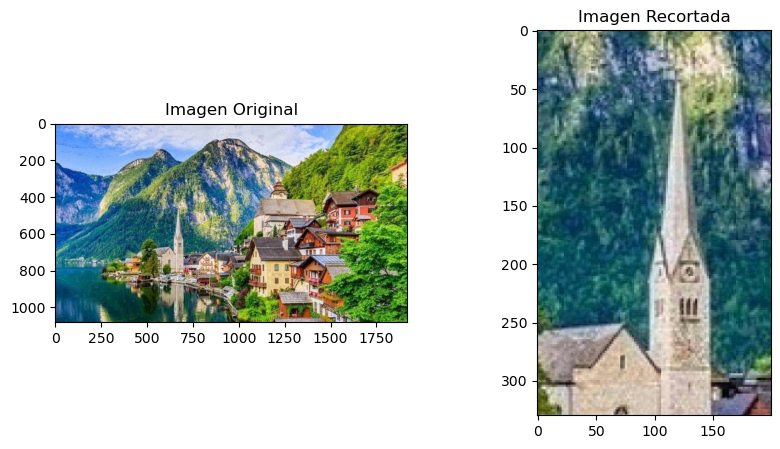

In [48]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('imagenP.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Imgane recortada 
img_recor = img_rgb[420:750, 550:750, :]

# guardar imagen
cv2.imwrite('imagenP.jpg', img_rgb)
plt.imsave('imagen_recortado.jpg',img_recor)

#Mostrar imagenes con axis
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')

fig_img = axs[1].imshow(img_recor)
axs[1].set_title('Imagen Recortada')






EJERCICIO 2

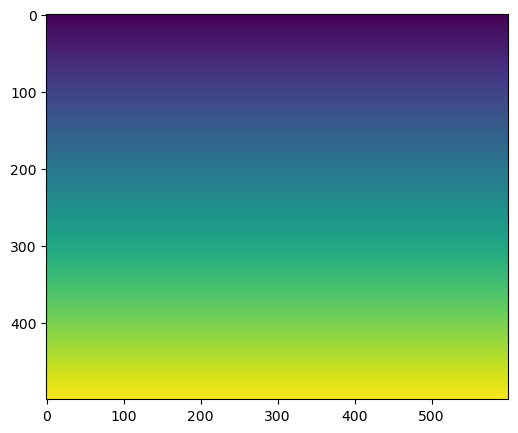

In [102]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


gradient = np.zeros((500, 600, 3), dtype=np.uint8)
for i in range(gradient.shape[0]):
    color = (i * 255 // gradient.shape[0], 255 - i * 255 // gradient.shape[0], 255)
    gradient[i, :] = color


img2 = plt.get_cmap('viridis')(gradient[:, :, 0] / 255.0)
plt.imshow(img2)


#Guardar imagen
plt.imsave('gradiente.jpg', img2)







EJERCICIO 3

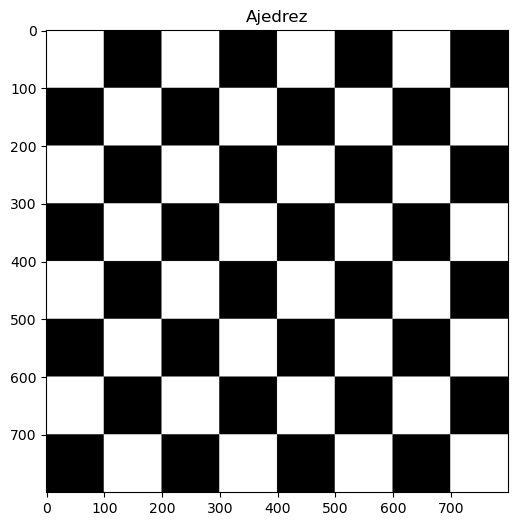

In [90]:
import matplotlib.pyplot as plt
import numpy as np

size_imagen = 800
rows, cols = 8, 8
cell_height = size_imagen // rows
cell_width = size_imagen // cols

imagen = np.zeros((size_imagen, size_imagen), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        y_start = i * cell_height
        x_start = j * cell_width
        y_end = (i + 1) * cell_height 
        x_end = (j + 1) * cell_width if j < cols - 1 else size_imagen

        #intercalar 
        valor = 255 if (i + j) % 2 == 0 else 0
        imagen[y_start:y_end, x_start:x_end] = valor

plt.figure(figsize=(6,6))
plt.imshow(imagen, cmap='gray')
plt.title('Ajedrez')
plt.axis('on')
plt.show()



EJERCICIO 4

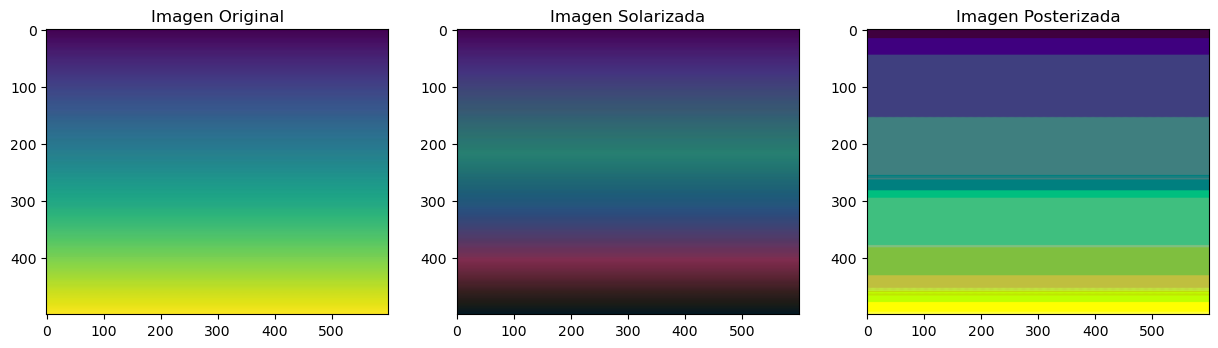

In [122]:
# PARTE 1
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('gradiente.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  


def posterizar(imagen,niveles):
    factor_escala = 255/niveles
    img_pos = np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

def solarizar(imagen, umbral):
    img_sol = np.where(imagen<umbral,imagen,255-imagen )
    return img_sol



umbral = 127
nvl = 4  

img_fin = solarizar(img_rgb, umbral)
img_fin2 = posterizar(img_rgb, nvl)


img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title('Imagen Original')
plt.imshow(img_rgb)
plt.subplot(1,3,2); plt.title('Imagen Solarizada')
plt.imshow(img_fin)
plt.subplot(1,3,3); plt.title('Imagen Posterizada')
plt.imshow(img_fin2)
plt.show()






In [ ]:
# PARTE 2
import os
import cv2
import numpy as np

paletas = [
    ('AUTUMN', cv2.COLORMAP_AUTUMN),
    ('BONE', cv2.COLORMAP_BONE),
    ('JET', cv2.COLORMAP_JET),
    ('WINTER', cv2.COLORMAP_WINTER),
    ('RAINBOW', cv2.COLORMAP_RAINBOW),
    ('OCEAN', cv2.COLORMAP_OCEAN),
    ('SUMMER', cv2.COLORMAP_SUMMER),
    ('SPRING', cv2.COLORMAP_SPRING),
    ('COOL', cv2.COLORMAP_COOL),
    ('HSV', cv2.COLORMAP_HSV),
    ('PINK', cv2.COLORMAP_PINK),
    ('HOT', cv2.COLORMAP_HOT),
]

img = cv2.imread('gradiente.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

out_dir = 'falso_color'
os.makedirs(out_dir, exist_ok=True)

for name, cmap in paletas:
    colored = cv2.applyColorMap(gray, cmap)     
    out_path = os.path.join(out_dir, f"{name}.png")
    cv2.imwrite(out_path, colored)



EJERCICIO 5

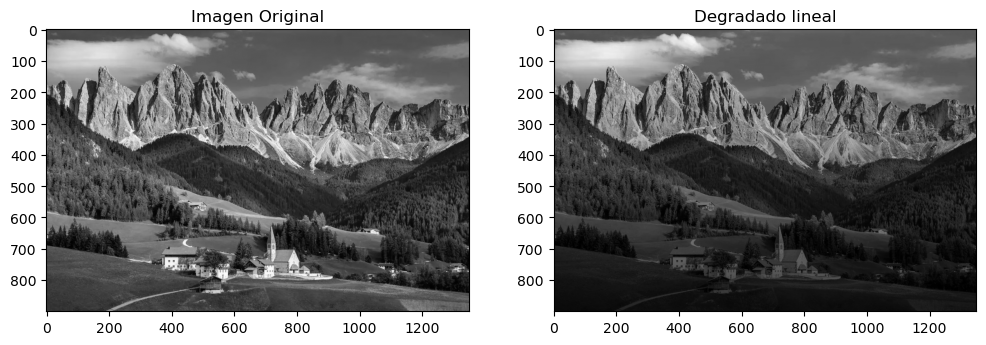

In [136]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

h, w = gray.shape[:2]
start, end = 1.0, 0.2
mask = np.linspace(start, end, h, dtype=np.float32)[:, None]       
mask = np.repeat(mask, w, axis=1)                                   

result = (gray.astype(np.float32) * mask).clip(0, 255).astype(np.uint8)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(gray, cmap='gray')
ax[0].set_title('Imagen Original')
ax[1].imshow(result, cmap='gray')
ax[1].set_title('Degradado lineal')
plt.show()



EJERCICIO 6

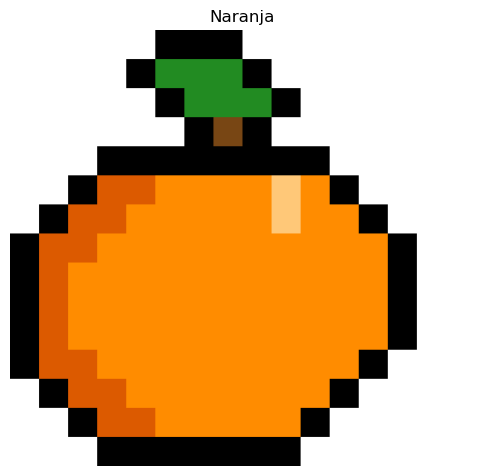

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

palette = {
    0: (255,255,255),   # fondo
    1: (0,0,0),         # borde
    2: (255,140,0),     # naranja base
    3: (220,90,0),      # sombra
    4: (255,200,120),   # brillo
    5: (34,139,34),     # hoja
    6: (120,70,20),     # tallo
}

mapa = np.array([

[0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,0,1,5,5,5,1,0,0,0,0,0,0,0],
[0,0,0,0,0,1,5,5,5,1,0,0,0,0,0,0],
[0,0,0,0,0,0,1,6,1,0,0,0,0,0,0,0],

[0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0],
[0,0,1,3,3,2,2,2,2,4,2,1,0,0,0,0],
[0,1,3,3,2,2,2,2,2,4,2,2,1,0,0,0],
[1,3,3,2,2,2,2,2,2,2,2,2,2,1,0,0],
[1,3,2,2,2,2,2,2,2,2,2,2,2,1,0,0],
[1,3,2,2,2,2,2,2,2,2,2,2,2,1,0,0],
[1,3,2,2,2,2,2,2,2,2,2,2,2,1,0,0],
[1,3,3,2,2,2,2,2,2,2,2,2,1,0,0,0],
[0,1,3,3,2,2,2,2,2,2,2,1,0,0,0,0],
[0,0,1,3,3,2,2,2,2,2,1,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0],

], dtype=np.uint8)

h, w = mapa.shape
img = np.zeros((h, w, 3), dtype=np.uint8)

for k, col in palette.items():
    img[mapa == k] = col

scale = 40
img_big = img.repeat(scale, axis=0).repeat(scale, axis=1)

plt.figure(figsize=(6,6))
plt.imshow(img_big)
plt.axis('off')
plt.title("Naranja")
plt.show()

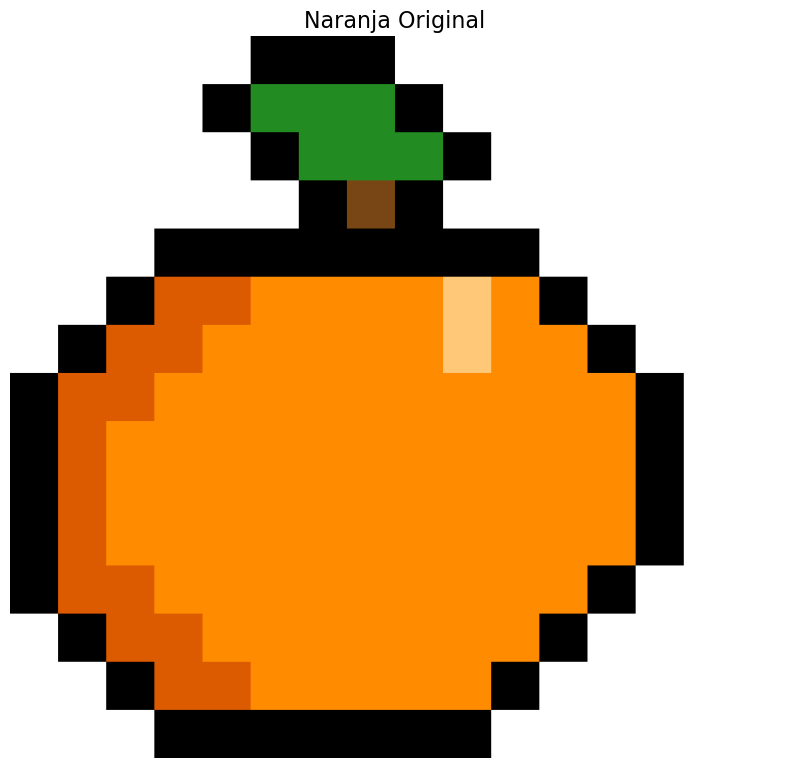

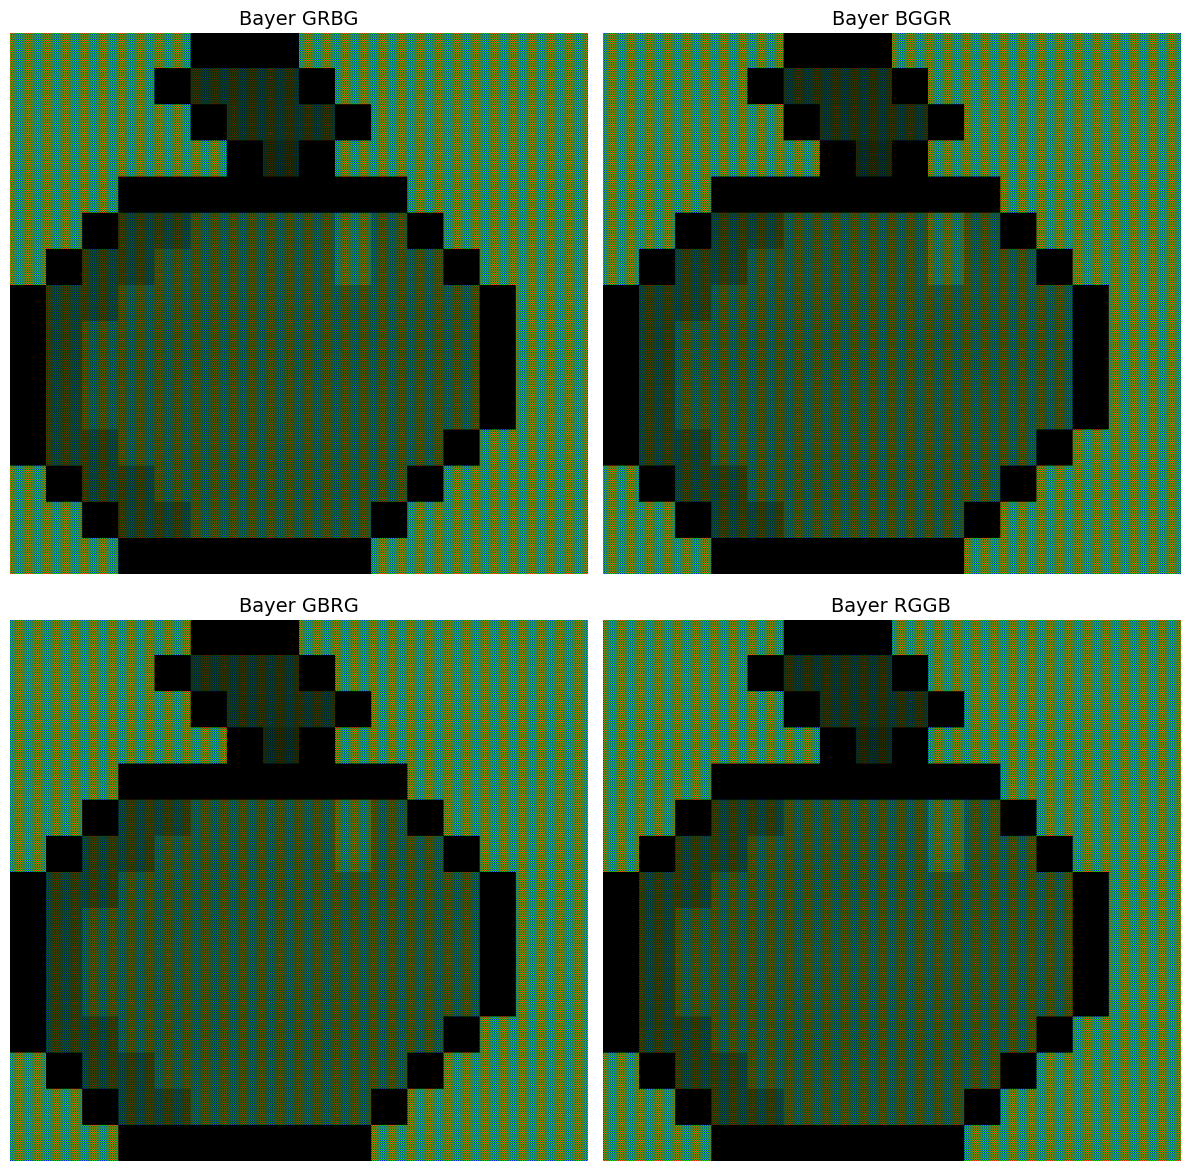

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Imagen original
plt.figure(figsize=(8,8))
plt.imshow(img_big)
plt.axis('off')
plt.title('Naranja Original', fontsize=16)
plt.tight_layout()
plt.show()

cv2.imwrite('naranja_original.png', cv2.cvtColor(img_big, cv2.COLOR_RGB2BGR))

gray = cv2.cvtColor(img_big, cv2.COLOR_RGB2GRAY)

# FILTRO BAYER

def bayer_grbg(gray):
    h, w = gray.shape
    bayer = np.zeros((h, w, 3), dtype=np.uint8)
    bayer[::2, ::2, 1] = gray[::2, ::2]
    bayer[::2, 1::2, 2] = gray[::2, 1::2]
    bayer[1::2, ::2, 0] = gray[1::2, ::2]
    bayer[1::2, 1::2, 1] = gray[1::2, 1::2]
    return bayer

def bayer_bggr(gray):
    h, w = gray.shape
    bayer = np.zeros((h, w, 3), dtype=np.uint8)
    bayer[::2, ::2, 0] = gray[::2, ::2]
    bayer[::2, 1::2, 1] = gray[::2, 1::2]
    bayer[1::2, ::2, 1] = gray[1::2, ::2]
    bayer[1::2, 1::2, 2] = gray[1::2, 1::2]
    return bayer

def bayer_gbrg(gray):
    h, w = gray.shape
    bayer = np.zeros((h, w, 3), dtype=np.uint8)
    bayer[::2, ::2, 1] = gray[::2, ::2]
    bayer[::2, 1::2, 0] = gray[::2, 1::2]
    bayer[1::2, ::2, 2] = gray[1::2, ::2]
    bayer[1::2, 1::2, 1] = gray[1::2, 1::2]
    return bayer

def bayer_rggb(gray):
    h, w = gray.shape
    bayer = np.zeros((h, w, 3), dtype=np.uint8)
    bayer[::2, ::2, 2] = gray[::2, ::2]
    bayer[::2, 1::2, 1] = gray[::2, 1::2]
    bayer[1::2, ::2, 1] = gray[1::2, ::2]
    bayer[1::2, 1::2, 0] = gray[1::2, 1::2]
    return bayer

bayer_images = {
    'GRBG': bayer_grbg(gray),
    'BGGR': bayer_bggr(gray),
    'GBRG': bayer_gbrg(gray),
    'RGGB': bayer_rggb(gray)
}

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for idx, (name, img_bayer) in enumerate(bayer_images.items()):
    row, col = idx // 2, idx % 2
    axs[row, col].imshow(img_bayer)
    axs[row, col].set_title(f'Bayer {name}', fontsize=14)
    axs[row, col].axis('off')
    cv2.imwrite(f'bayer_{name}.png', cv2.cvtColor(img_bayer, cv2.COLOR_RGB2BGR))

plt.tight_layout()
plt.show()